In [13]:
# -------------------------------
# 1. IMPORT LIBRARIES
# -------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)

import xgboost as xgb
from imblearn.pipeline import Pipeline as ImbPipeline  # for SMOTE in pipeline
from imblearn.over_sampling import SMOTE

import joblib
import warnings
warnings.filterwarnings('ignore')

# For EDA plots
# if in Jupyter
%matplotlib inline

In [17]:
from google.colab import drive
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/diabetes_prediction_dataset.csv'
try:
    df = pd.read_csv(file_path)
    print("Dataset loaded successfully from Google Drive.")
    print("Dataset shape:", df.shape)
except FileNotFoundError:
    print(f"Error: File not found at {file_path}. Please check the path.")
    raise
df.head()

Mounted at /content/drive
Dataset loaded successfully from Google Drive.
Dataset shape: (100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0



=== Numeric Summary ===
                 age            bmi    HbA1c_level  blood_glucose_level
count  100000.000000  100000.000000  100000.000000        100000.000000
mean       41.885856      27.320767       5.527507           138.058060
std        22.516840       6.636783       1.070672            40.708136
min         0.080000      10.010000       3.500000            80.000000
25%        24.000000      23.630000       4.800000           100.000000
50%        43.000000      27.320000       5.800000           140.000000
75%        60.000000      29.580000       6.200000           159.000000
max        80.000000      95.690000       9.000000           300.000000


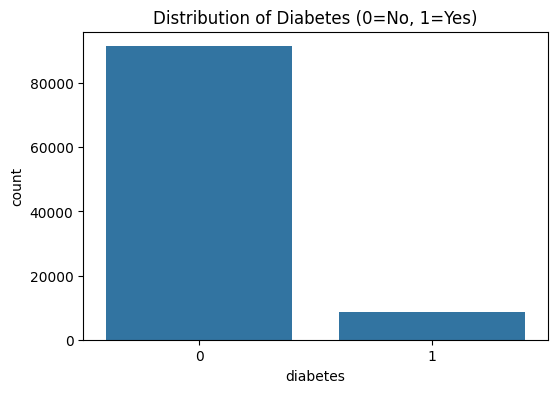

Class distribution:
diabetes
0    91500
1     8500
Name: count, dtype: int64
Percentage of positive cases: 8.50%


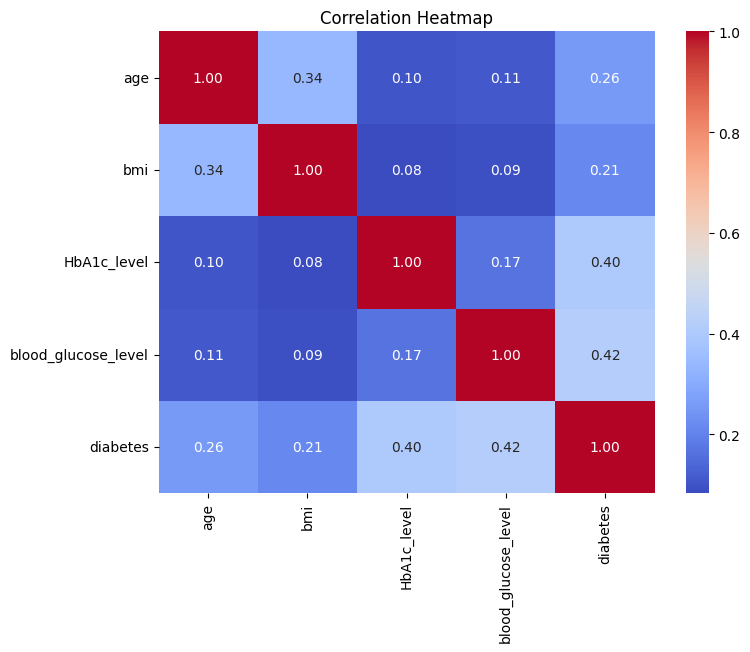

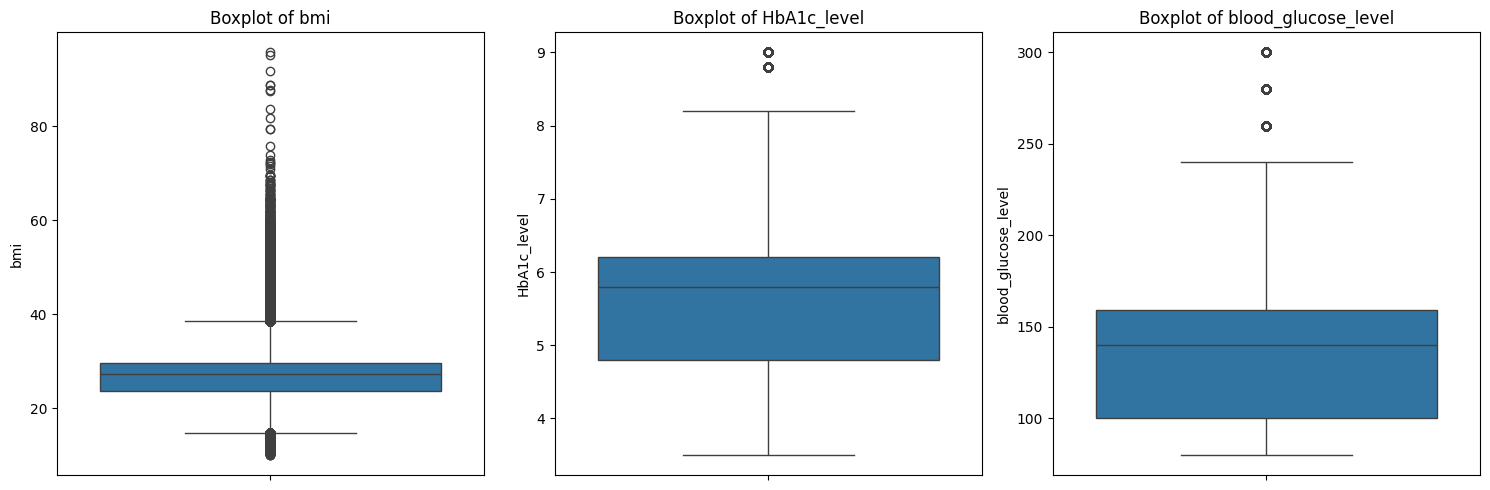

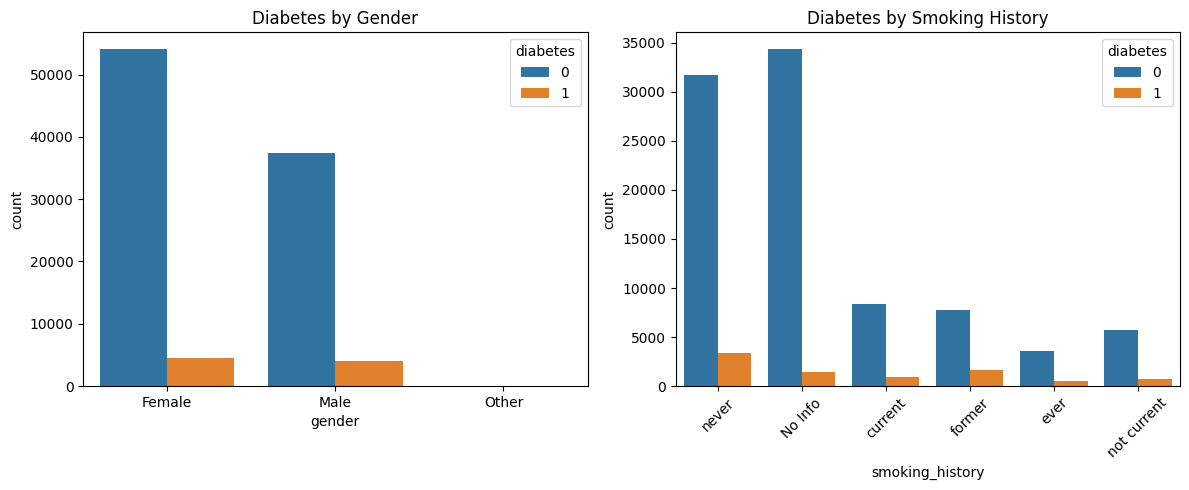

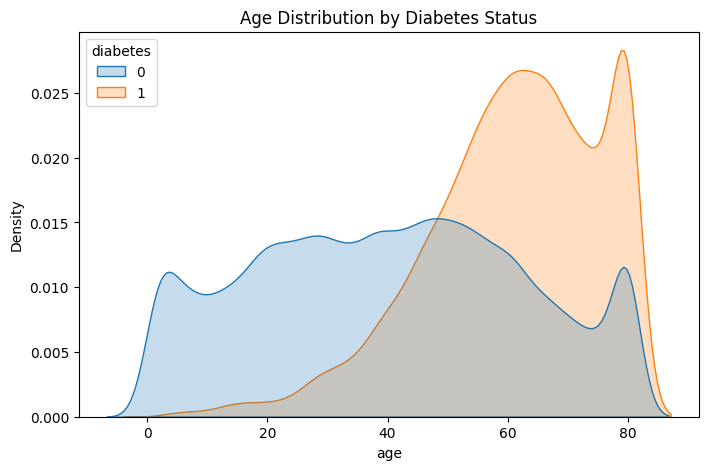

In [18]:
# -------------------------------
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# -------------------------------

# 3.1 Statistical summary of numeric columns
numeric_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
print("\n=== Numeric Summary ===")
print(df[numeric_cols].describe())

# 3.2 Target distribution (imbalance check)
plt.figure(figsize=(6,4))
sns.countplot(x='diabetes', data=df)
plt.title('Distribution of Diabetes (0=No, 1=Yes)')
plt.show()
print(f"Class distribution:\n{df['diabetes'].value_counts()}")
print(f"Percentage of positive cases: {df['diabetes'].mean()*100:.2f}%")

# 3.3 Correlation heatmap (numeric features vs target)
plt.figure(figsize=(8,6))
corr = df[numeric_cols + ['diabetes']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# 3.4 Box plots for outliers
fig, axes = plt.subplots(1, 3, figsize=(15,5))
for idx, col in enumerate(['bmi', 'HbA1c_level', 'blood_glucose_level']):
    sns.boxplot(y=col, data=df, ax=axes[idx])
    axes[idx].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# 3.5 Relationship between categorical features and target
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.countplot(x='gender', hue='diabetes', data=df, ax=axes[0])
axes[0].set_title('Diabetes by Gender')
sns.countplot(x='smoking_history', hue='diabetes', data=df, ax=axes[1])
axes[1].set_title('Diabetes by Smoking History')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Additional insight: check age distribution by diabetes
plt.figure(figsize=(8,5))
sns.kdeplot(data=df, x='age', hue='diabetes', fill=True, common_norm=False)
plt.title('Age Distribution by Diabetes Status')
plt.show()

In [19]:
# -------------------------------
# 4. DATA PREPROCESSING PIPELINE
# -------------------------------

# Define feature types
categorical_cols = ['gender', 'smoking_history']
numerical_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
target = 'diabetes'

# Handle 'Other' in gender: treat as missing and impute with mode
def preprocess_gender(df):
    df = df.copy()
    # Map Male->1, Female->0, others->NaN
    df['gender'] = df['gender'].map({'Male': 1, 'Female': 0, 'Other': np.nan})
    return df

# Custom transformer for gender preprocessing
from sklearn.base import BaseEstimator, TransformerMixin
class GenderPreprocessor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        X['gender'] = X['gender'].map({'Male': 1, 'Female': 0, 'Other': np.nan})
        return X

# Preprocessing for numerical: impute with median, then scale
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Preprocessing for categorical: impute with mode, then one-hot encode
# For gender, after mapping we treat as numeric, but we can also one-hot encode.
# Since requirement: binary encode gender, we'll handle gender separately.
# We'll treat smoking_history with one-hot.
# But we need to include gender in the preprocessing.

# For gender: we'll use the custom transformer to map, then we can either use as numeric (0/1) or one-hot.
# To keep it binary, we'll impute missing gender with mode and keep as numeric.
# But we must ensure the imputation happens after mapping.
# We'll create a pipeline for gender:
gender_transformer = Pipeline(steps=[
    ('map', GenderPreprocessor()),
    ('imputer', SimpleImputer(strategy='most_frequent'))  # impute with mode
])

# For smoking_history: one-hot encode, treat 'No Info' as distinct category.
smoking_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_cols),
        ('gender', gender_transformer, ['gender']),  # only gender column
        ('smoking', smoking_transformer, ['smoking_history'])
    ],
    remainder='drop'  # drop any other columns (none)
)

# Test the preprocessor on a small sample
sample = df.head(5)
print("\nPreprocessor test (sample):")
print(preprocessor.fit_transform(sample).shape)



Preprocessor test (sample):
(5, 8)


In [21]:
# -------------------------------
# 5. MODELING PIPELINE WITH SMOTE
# -------------------------------

# Define models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
}

# For each model, build a pipeline: preprocessor -> SMOTE -> classifier
pipelines = {}
for name, model in models.items():
    pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('classifier', model)
    ])
    pipelines[name] = pipeline

# Split data into train and test (stratified)
X = df.drop(columns=[target])
y = df[target]

# استخدم train_test_split مع stratify للحفاظ على توزيع الفئات
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining set size: {X_train.shape[0]}, Test set size: {X_test.shape[0]}")


Training set size: 80000, Test set size: 20000


In [22]:
# -------------------------------
# 6. TRAIN AND COMPARE MODELS
# -------------------------------

# We'll train each model and collect evaluation metrics on the test set.
results = {}
for name, pipeline in pipelines.items():
    print(f"\nTraining {name}...")
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]  # probability of positive class

    # Compute metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1': f1,
        'ROC-AUC': roc_auc,
        'Pipeline': pipeline,  # store trained pipeline for later
        'y_pred': y_pred,
        'y_proba': y_proba
    }
    print(f"  Accuracy: {acc:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}, ROC-AUC: {roc_auc:.4f}")

# Display comparison dataframe
results_df = pd.DataFrame({
    name: {metric: results[name][metric] for metric in ['Accuracy','Precision','Recall','F1','ROC-AUC']}
    for name in results
}).T
print("\n=== Model Comparison ===")
print(results_df)


Training Logistic Regression...
  Accuracy: 0.8841, Recall: 0.8906, F1: 0.5665, ROC-AUC: 0.9618

Training Random Forest...
  Accuracy: 0.9589, Recall: 0.7400, F1: 0.7537, ROC-AUC: 0.9656

Training XGBoost...
  Accuracy: 0.9690, Recall: 0.7018, F1: 0.7937, ROC-AUC: 0.9762

=== Model Comparison ===
                     Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression   0.88415   0.415364  0.890588  0.566511  0.961821
Random Forest         0.95890   0.768010  0.740000  0.753745  0.965649
XGBoost               0.96900   0.913476  0.701765  0.793746  0.976164


In [23]:
# -------------------------------
# 7. HYPERPARAMETER TUNING FOR XGBOOST
# -------------------------------

# Since XGBoost performed well, we tune it further.
xgb_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
])

# Define parameter grid
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [3, 5, 7],
    'classifier__learning_rate': [0.01, 0.1, 0.2],
    'classifier__subsample': [0.8, 1.0],
    'classifier__colsample_bytree': [0.8, 1.0]
}

# Use GridSearchCV with 3-fold (to save time) but 5-fold is also okay
# We'll use 3-fold for speed, but you can increase.
grid_search = GridSearchCV(
    xgb_pipeline,
    param_grid,
    cv=3,
    scoring='roc_auc',  # optimize for ROC-AUC
    n_jobs=-1,
    verbose=1
)

print("\nStarting GridSearchCV for XGBoost...")
grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV ROC-AUC: {grid_search.best_score_:.4f}")

# Retrieve best model
best_xgb = grid_search.best_estimator_

# Evaluate tuned XGBoost on test set
y_pred_tuned = best_xgb.predict(X_test)
y_proba_tuned = best_xgb.predict_proba(X_test)[:, 1]
tuned_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned),
    'Recall': recall_score(y_test, y_pred_tuned),
    'F1': f1_score(y_test, y_pred_tuned),
    'ROC-AUC': roc_auc_score(y_test, y_proba_tuned)
}
print("\n=== Tuned XGBoost Performance ===")
for k, v in tuned_metrics.items():
    print(f"{k}: {v:.4f}")

# Update results with tuned XGBoost
results['Tuned XGBoost'] = {
    **tuned_metrics,
    'Pipeline': best_xgb,
    'y_pred': y_pred_tuned,
    'y_proba': y_proba_tuned
}


Starting GridSearchCV for XGBoost...
Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters: {'classifier__colsample_bytree': 1.0, 'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 300, 'classifier__subsample': 0.8}
Best CV ROC-AUC: 0.9774

=== Tuned XGBoost Performance ===
Accuracy: 0.9675
Precision: 0.8651
Recall: 0.7318
F1: 0.7929
ROC-AUC: 0.9778



=== Final Model (Tuned XGBoost) ===
Accuracy: 0.9675
Precision: 0.8651
Recall: 0.7318
F1 Score: 0.7929
ROC-AUC: 0.9778

Confusion Matrix:
[[18106   194]
 [  456  1244]]


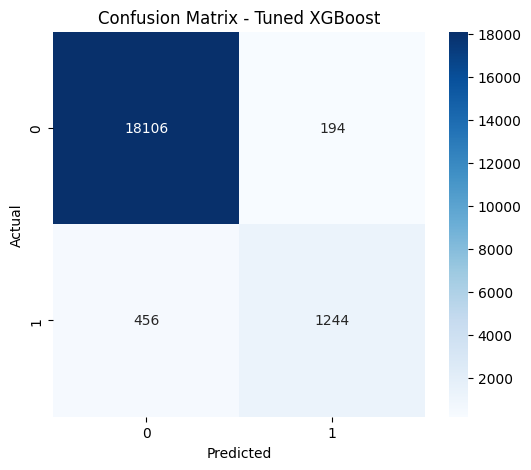


Top 10 Feature Importances:
                feature  importance
2           HbA1c_level    0.385936
3   blood_glucose_level    0.261172
0                   age    0.122096
5       smoking_No Info    0.093585
1                   bmi    0.089287
4                gender    0.016938
8        smoking_former    0.010017
7          smoking_ever    0.007970
10  smoking_not current    0.006090
9         smoking_never    0.005417


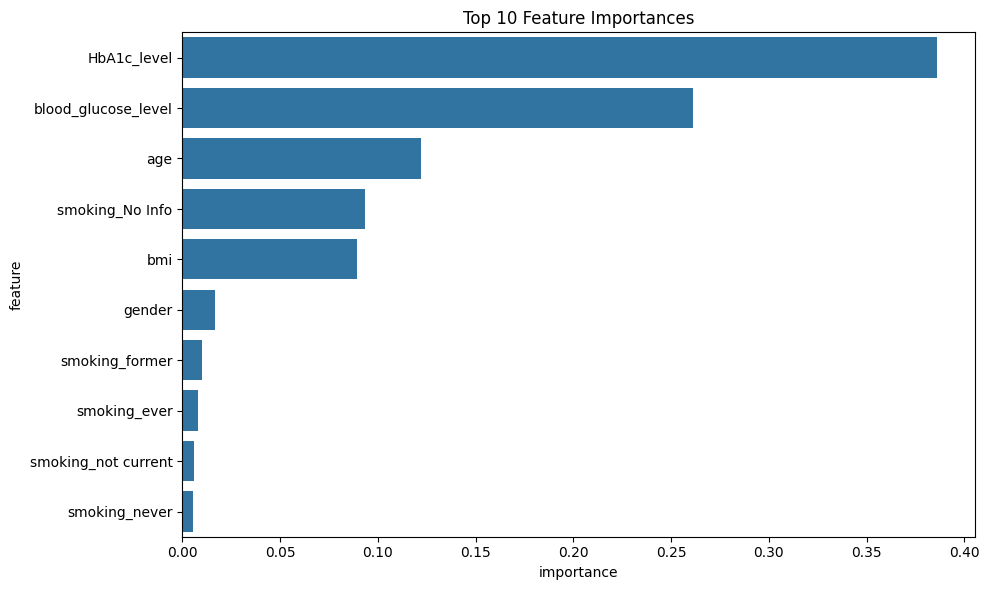

In [24]:

# -------------------------------
# 8. FINAL EVALUATION & INTERPRETATION
# -------------------------------

# Choose the best model (in this case, tuned XGBoost if better)
best_model = best_xgb
best_metrics = tuned_metrics
best_y_pred = y_pred_tuned
best_y_proba = y_proba_tuned

print("\n=== Final Model (Tuned XGBoost) ===")
print(f"Accuracy: {best_metrics['Accuracy']:.4f}")
print(f"Precision: {best_metrics['Precision']:.4f}")
print(f"Recall: {best_metrics['Recall']:.4f}")
print(f"F1 Score: {best_metrics['F1']:.4f}")
print(f"ROC-AUC: {best_metrics['ROC-AUC']:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, best_y_pred)
print("\nConfusion Matrix:")
print(cm)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Tuned XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Clinical note: Recall is critical because missing a diabetes case (false negative)
# can lead to serious health complications. We prioritize high recall to avoid
# missing patients who actually have diabetes.

# Feature Importance (for tree-based models)
# Extract feature names after preprocessing
# We need to get feature names from the preprocessor.
# First, fit preprocessor on training data to get feature names.
preprocessor.fit(X_train)  # fit on training data
# Get feature names for numerical (original names)
num_features = numerical_cols
# For gender, it's just 'gender' (since we mapped to numeric)
gender_feature = ['gender']
# For smoking_history, get one-hot encoded feature names
smoking_encoder = preprocessor.named_transformers_['smoking'].named_steps['onehot']
smoking_categories = smoking_encoder.categories_[0]  # from fitted encoder
smoking_features = [f'smoking_{cat}' for cat in smoking_categories]
all_feature_names = num_features + gender_feature + smoking_features

# Get feature importance from the best model (XGBoost)
if hasattr(best_model.named_steps['classifier'], 'feature_importances_'):
    importances = best_model.named_steps['classifier'].feature_importances_
    # Create DataFrame
    feat_imp = pd.DataFrame({'feature': all_feature_names, 'importance': importances})
    feat_imp = feat_imp.sort_values('importance', ascending=False)
    print("\nTop 10 Feature Importances:")
    print(feat_imp.head(10))

    # Plot
    plt.figure(figsize=(10,6))
    sns.barplot(data=feat_imp.head(10), x='importance', y='feature')
    plt.title('Top 10 Feature Importances')
    plt.tight_layout()
    plt.show()


In [25]:
# Save the full pipeline
joblib.dump(best_model, 'diabetes_prediction_pipeline.joblib')
print("\nModel saved as 'diabetes_prediction_pipeline.joblib'")

# Also save the preprocessor separately (optional)
joblib.dump(preprocessor, 'preprocessor.joblib')
print("Preprocessor saved as 'preprocessor.joblib'")



Model saved as 'diabetes_prediction_pipeline.joblib'
Preprocessor saved as 'preprocessor.joblib'


Full pipeline with explainer saved as 'hikmarisk_inference_engine.pkl'


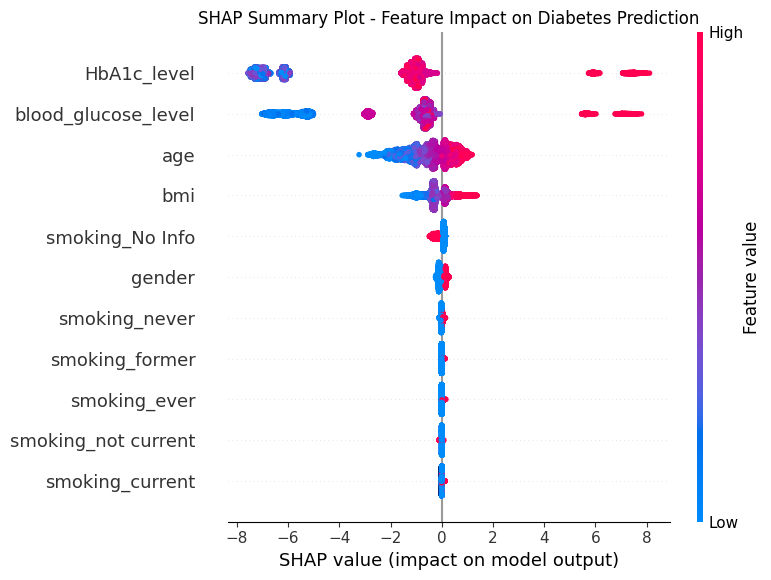

SHAP explainer and summary plot generated successfully.


In [26]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# After best_model is defined and trained (Tuned XGBoost)
# Extract the trained XGBoost classifier from the pipeline
xgb_model = best_model.named_steps['classifier']

# Fit the preprocessor on training data to get feature names
preprocessor.fit(X_train)
# Get feature names for numerical columns
num_features = numerical_cols
# Gender feature (after mapping)
gender_feature = ['gender']
# One-hot encoded smoking history feature names
smoking_encoder = preprocessor.named_transformers_['smoking'].named_steps['onehot']
smoking_categories = smoking_encoder.categories_[0]
smoking_features = [f'smoking_{cat}' for cat in smoking_categories]
all_feature_names = num_features + gender_feature + smoking_features

# Create SHAP TreeExplainer
explainer = shap.TreeExplainer(xgb_model)

# Save the explainer along with the model and preprocessor in a single dictionary
full_pipeline = {
    'preprocessor': preprocessor,
    'model': xgb_model,
    'explainer': explainer,
    'feature_names': all_feature_names
}

# Save the full pipeline object
joblib.dump(full_pipeline, 'hikmarisk_inference_engine.pkl')
print("Full pipeline with explainer saved as 'hikmarisk_inference_engine.pkl'")

# Optional: Generate SHAP summary plot for the test set (for model interpretation)
X_test_processed = preprocessor.transform(X_test)
if hasattr(X_test_processed, "toarray"):
    X_test_processed = X_test_processed.toarray()

shap_values_test = explainer.shap_values(X_test_processed)

# Summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_test, X_test_processed, feature_names=all_feature_names, show=False)
plt.title('SHAP Summary Plot - Feature Impact on Diabetes Prediction')
plt.tight_layout()
plt.savefig('shap_summary_plot.png', dpi=150, bbox_inches='tight')
plt.show()

# Save SHAP values for test set (optional)
np.save('shap_values_test.npy', shap_values_test)

print("SHAP explainer and summary plot generated successfully.")